# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load dataset

In [2]:
df = pd.read_csv("netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [5]:
df.shape

(8807, 12)

In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

# 3. Dataset Familiarization

In [7]:
# No of rows and columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8807
Columns: 12


In [8]:
#Check data types and non-null Counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [9]:
# summary statistics for numerical columns
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [10]:
# sumarry of categorical columns
df.describe(include='object')

C:\Users\HomePC\AppData\Local\Temp\ipykernel_17244\743090778.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [13]:
for col in df.columns:
    print(col, ":", df[col].nunique())

show_id : 8807
type : 2
title : 8807
director : 4528
cast : 7692
country : 748
date_added : 1767
release_year : 74
rating : 17
duration : 220
listed_in : 514
description : 8775


In [ ]:
# content types
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [15]:
# rating 
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

# 4. Data Quality Assessment

In [16]:
# check missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [17]:
# % of missing values
(df.isnull().sum() / len(df)) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [21]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

In [22]:
df['show_id'].duplicated().sum()

np.int64(0)

In [23]:
(df == '').sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [27]:
# missing counties 
df['country'].isnull().sum()

np.int64(831)

In [28]:
# missing dates 
df['date_added'].isnull().sum()

np.int64(10)

# 5. Data cleaning 

In [29]:
netflix = df.copy()

In [30]:
# standardize column names
netflix.columns = netflix.columns.str.lower().str.strip().str.replace(' ', '_')

In [31]:
netflix.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [35]:
netflix['date_added'] = netflix['date_added'].str.strip()
netflix['date_added'] = pd.to_datetime(netflix['date_added'])

In [36]:
netflix['date_added'].dtype

dtype('<M8[us]')

In [38]:
# missing values
netflix['director'] = netflix['director'].fillna('Unknown')

In [39]:
netflix['cast'] = netflix['cast'].fillna('Unknown')

In [40]:
netflix['country'] = netflix['country'].fillna('Unknown')


In [41]:
netflix['rating'] = netflix['rating'].fillna(netflix['rating'].mode()[0])

In [42]:
netflix['duration'] = netflix['duration'].fillna(netflix['duration'].mode()[0])

In [43]:
netflix = netflix.dropna(subset=['date_added'])

In [44]:
# remove duplicates
netflix.drop_duplicates(inplace=True)

In [45]:
netflix.duplicated().sum()

np.int64(0)

In [46]:
# removing leading spaces
for col in netflix.select_dtypes(include='object'):
    netflix[col] = netflix[col].str.strip()

C:\Users\HomePC\AppData\Local\Temp\ipykernel_17244\3393928964.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in netflix.select_dtypes(include='object'):


In [47]:
# checking on dates
netflix[(netflix['release_year'] < 1900) | (netflix['release_year'] > 2026)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [48]:
# validating columns
netflix['type'].unique()

<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

In [49]:
netflix['rating'].unique()

<StringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',   '74 min',
   '84 min',   '66 min',       'NR', 'TV-Y7-FV',       'UR']
Length: 17, dtype: str

In [50]:
netflix.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [51]:
netflix.duplicated().sum()

np.int64(0)

In [52]:
netflix.shape

(8797, 12)

In [53]:
netflix.info()

<class 'pandas.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   str           
 1   type          8797 non-null   str           
 2   title         8797 non-null   str           
 3   director      8797 non-null   str           
 4   cast          8797 non-null   str           
 5   country       8797 non-null   str           
 6   date_added    8797 non-null   datetime64[us]
 7   release_year  8797 non-null   int64         
 8   rating        8797 non-null   str           
 9   duration      8797 non-null   str           
 10  listed_in     8797 non-null   str           
 11  description   8797 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 893.4 KB


In [54]:
# saving dataset 
netflix.to_csv("netflix_cleaned.csv", index=False)

In [55]:
cleaned_df = pd.read_csv("netflix_cleaned.csv")
cleaned_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# 6.  EDA

## Top Countries 

In [57]:
country_count = netflix['country'].str.split(', ', expand=True).stack().value_counts()
country_count.head(10)

United States     3683
India             1046
Unknown            830
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

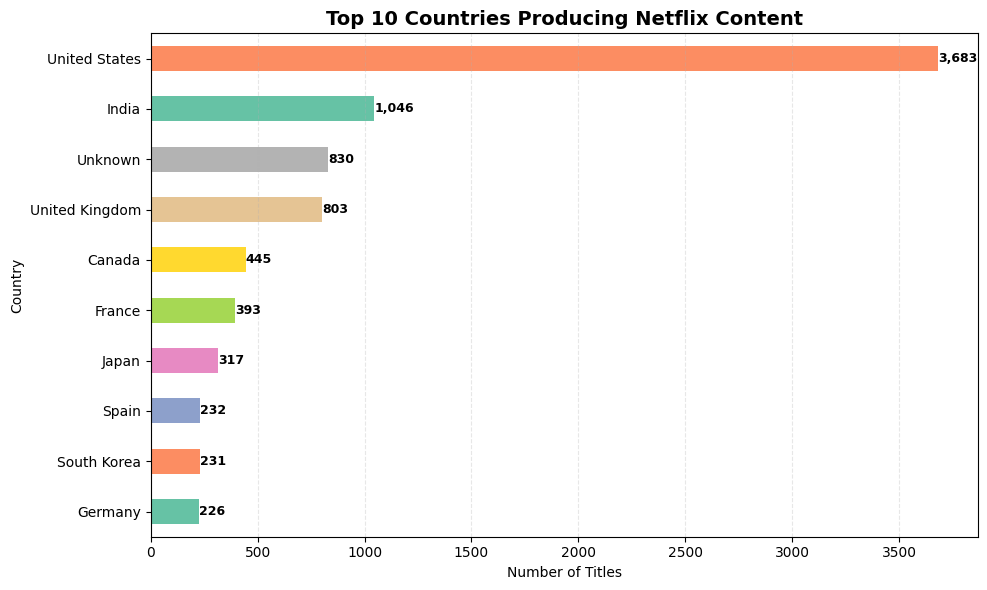

In [78]:
plt.figure(figsize=(10,6))

ax = country_count.head(10).sort_values().plot(
    kind='barh',
    color=sns.color_palette("Set2", len(country_count.head(10)))
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_width()):,}',
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title(
    'Top 10 Countries Producing Netflix Content',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#### Business Insight 

The United States is the primary source of Netflix content, contributing more titles than all other countries combined among the top producers, while India and the United Kingdom are the leading international contributors.

## Movies vs TV Shows

In [59]:
netflix['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

C:\Users\HomePC\AppData\Local\Temp\ipykernel_17244\2260148593.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


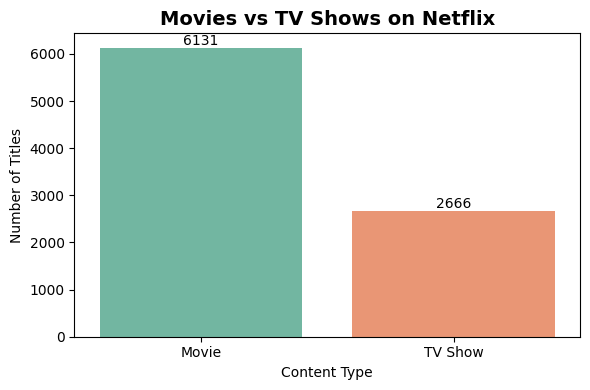

In [77]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=netflix,
    x='type',
    palette='Set2'
)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Movies vs TV Shows on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.tight_layout()
plt.show()

#### Business Insight 

Netflix's catalog is heavily focused on movies, with movies outnumbering TV shows by more than two to one. This suggests that Netflix places greater emphasis on film content to attract and retain viewers.

## Rating Distribution

In [61]:
netflix['rating'].value_counts()

rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

C:\Users\HomePC\AppData\Local\Temp\ipykernel_17244\1999149953.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


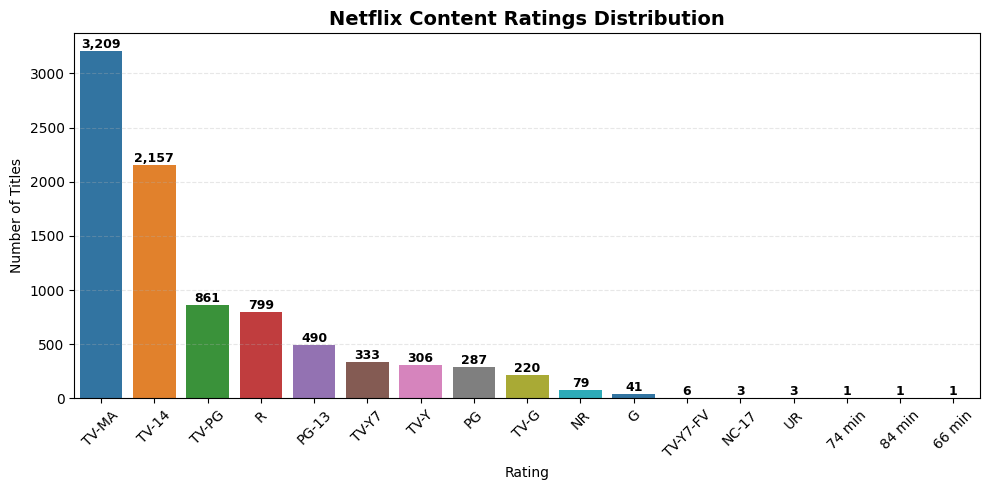

In [79]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=netflix,
    x='rating',
    order=netflix['rating'].value_counts().index,
    palette='tab10'
)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.title(
    'Netflix Content Ratings Distribution',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Rating')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#### Business Insight

Netflix's content library is mainly geared toward teenagers and adults. The most common ratings are TV-MA and TV-14, showing that the platform focuses more on mature entertainment such as dramas, thrillers, documentaries, and reality shows than on children's programming.

## Content added to Netflix over time

In [63]:
netflix['year_added'] = netflix['date_added'].dt.year

In [64]:
added_year = netflix['year_added'].value_counts().sort_index()

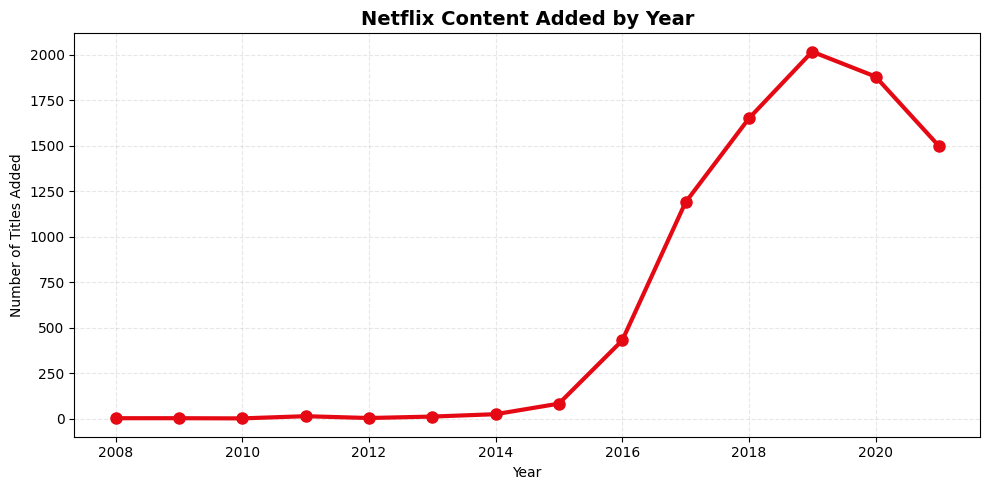

In [80]:
plt.figure(figsize=(10,5))

ax = added_year.plot(
    marker='o',
    linewidth=3,
    markersize=8,
    color='#E50914'  # Netflix red
)

# Add values on points
for x, y in enumerate(added_year):
    ax.annotate(
        f'{y:,}',
        (x, y),
        textcoords="offset points",
        xytext=(0,8),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title(
    'Netflix Content Added by Year',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Year')
plt.ylabel('Number of Titles Added')

plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

##### Business Insight

Netflix's content library grew steadily in its early years but expanded rapidly after 2015. This suggests that the company invested heavily in acquiring and producing content as it expanded into new markets around the world.

## Top Genres 

In [66]:
genre_count = netflix['listed_in'].str.split(', ', expand=True).stack().value_counts()
genre_count.head(10)

International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

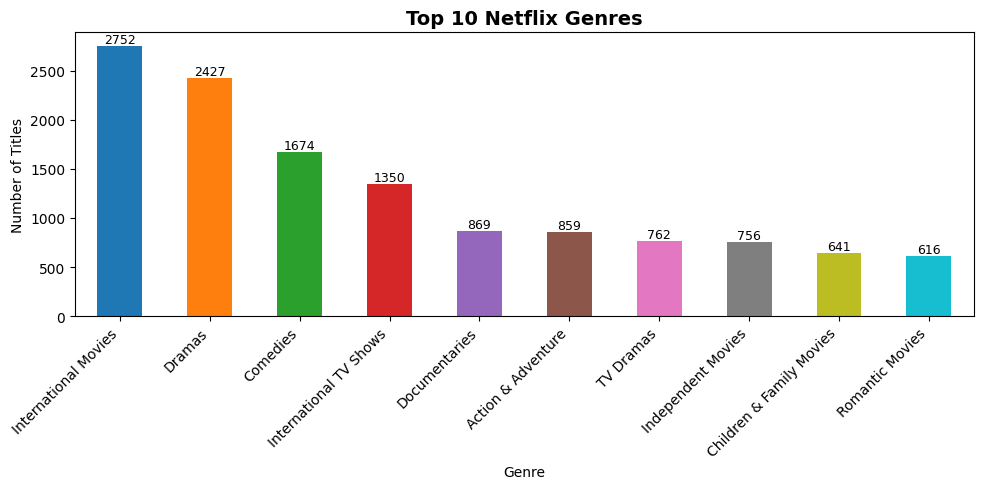

In [76]:
plt.figure(figsize=(10,5))

ax = genre_count.head(10).plot(
    kind='bar',
    color=sns.color_palette("tab10", len(genre_count.head(10)))
)

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Top 10 Netflix Genres', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

#### Business Insight

International Movies are the most common genre on Netflix, highlighting the platform's global content strategy. Dramas and Comedies also make up a large share of the catalog, suggesting that viewers are drawn to engaging stories and light-hearted entertainment from different parts of the world.

## Content release trends

In [68]:
release_trend = netflix['release_year'].value_counts().sort_index()
release_trend.head()

release_year
1925    1
1942    2
1943    3
1944    3
1945    4
Name: count, dtype: int64

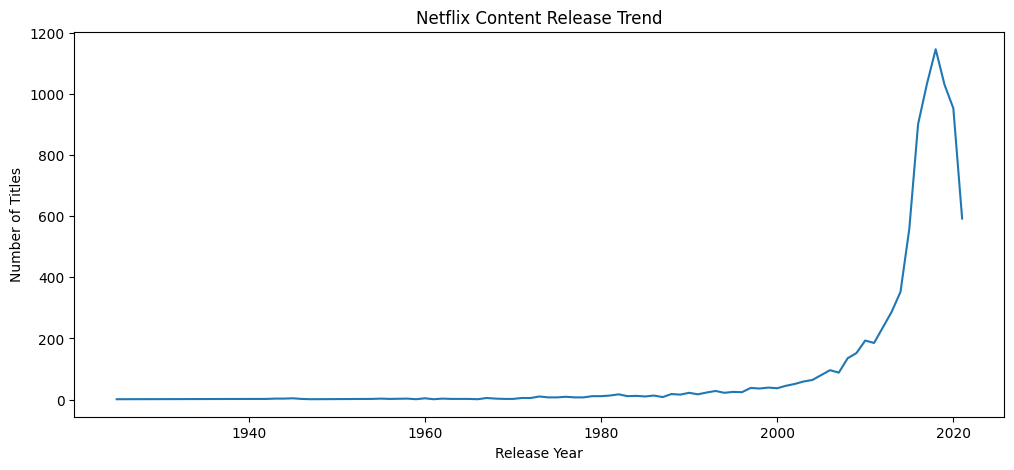

In [ ]:
plt.figure(figsize=(12,5))
release_trend.plot()
plt.title('Netflix Content Release Trend')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()


# Shows when the movies and TV shows were originally released.

#### Business Insights

Most of Netflix's catalog consists of relatively recent content. The sharp increase in releases after 2015 shows Netflix's focus on expanding its library with newer movies and TV shows to keep viewers engaged and attract a global audience.

In [70]:
netflix.to_csv("netflix_cleaned.csv", index=False)

In [71]:
netflix.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description',
 'year_added']

In [72]:
netflix.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021


In [73]:
netflix = netflix.drop(columns=['year_added'])

In [74]:
netflix.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [75]:
netflix.to_csv("netflix_cleaned.csv", index=False)